<style>
    pre {
        white-space: pre-wrap;
        word-wrap: break-word;
    }
</style>

<div style="display:flex; justify-content:space-around; align-items:center; background-color:#cccccc; padding:5px; border:2px solid #333333;">
    <a href="https://www.um.es/web/estudios/grados/ciencia-ingenieria-datos/" target="_blank">
    <img src="images/umu_logo.png" alt="UMU" style="height:200px; width:auto;">
    <a href="https://estudios.upct.es/grado/5251/inicio" target="_blank">
    <img src="images/upct_logo.png" alt="UPCT" style="height:145px; width:auto;">
</div>


# Asignatura: **Deep Learning**

## Titulación: **Grado en Ciencia e Ingeniería de Datos**

## Práctica 2: Redes Convolucionales
### **Sesión 3/3: Segmentación de imágenes**

**Autores**: Antonio Martínez Sánchez, Juan Morales Sánchez, José Luís Sancho Gómez y Juan Antonio Botía Blaya

<div style="page-break-before: always;"></div>

### Contenidos
- [Requisitos](#requisitos)
- [Segmentación de imágenes](#segmentacion)
- [El dataset](#dataset)
- [Ejercicios](#ejercicios)
- [Ejercicios extra: reconstrucción 3D](#3D)

### Requisitos
<a class='anchor' id='requisitos'></a>

Se trabajará con notebooks de [Jupyter](https://jupyter.org/install) con código Python empleando como intérprete la última versión de [Miniconda](https://docs.anaconda.com/miniconda/). Se requiere la preinstalación (se recomienda utilizar [pip](https://pypi.org/project/pip/)) de los siguientes paquetes de Python:

- [Numpy](https://pypi.org/project/numpy/) (computación numérica)
- [Scipy](https://pypi.org/project/scipy/) (computación científica)
- [Tensorflow](https://www.tensorflow.org/install/pip?hl=es-419#linux) que incluye a Keras (deep Learning)
- [Scikit-learn](https://pypi.org/project/scikit-learn/) (machine Learning)
- [Mrcfile](https://pypi.org/project/mrcfile/) (operaciones E/S para ficheros MRC)
- [Matplotlib](https://pypi.org/project/matplotlib/) and [Seaborn](https://pypi.org/project/seaborn/) (visualización de datos)

Además, para la visualización 3D se recomienda la utilización de [Paraview](https://www.paraview.org/).

### Segmentación de imágenes
<a class='anchor' id='segmentacion'></a>

En esta sección vamos a adaptar la red U-Net que construimos para restaurar imágenes en la sección anterior, en esta sección la usaremos para segmentar las imágenes contenidas en tomogramas. **Un tomograma es una imagen volumétrica (3D) donde los píxeles, cuadrados, pasan a ser vóxeles, cubos.** No obstante, ahora no vamos a procesar los tomogramas completos, si no que vamos a ir extrayendo cortes, imágenes 2D, para procesarlos de manera independiente. Trabajar en 3D suele requerir de unos recursos computacionales mayores de los que presenta un ordenador de escritorio. 

Un tomograma tiene tres ejes: $X$, $Y$ y $Z$. Por lo que se pueden realizar cortes directos (no requieren de interpolaciones complejas): 

* en los planos $X-Y$ a lo largo de todas las coordenadas del eje $Z$, 

* en los planos $X-Z$ a lo largo de todas las coordenadas del eje $Y$ y 

* en los planos $Y-Z$ a lo largo de todas las coordenadas del eje $X$. 

La siguiente imagen permite visualizar un ejemplo de corte en los planos X-Y, X-Z e Y-Z para un tomograma.

![TomoSlices](images/tomo_slices.png)

### Segmentación Semántica

El problema de **segmentación semántica** consiste en clasificar todos los píxeles (o vóxeles) de una imagen mediante la asignación de una etiqueta a cada elemento. Es una de las tareas más complejas en visión por computador, se necesita analizar un entorno amplio de las imágenes para determinar su contenido, pero a la vez hay que ser preciso en la asignación de las clases para cada píxel. En 2015 la arquitectura U-Net se diseñó para resolver el problema de la segmentación de imágenes y aún sigue siendo la más exitosa para resolver esta tarea.

### El dataset
<a class='anchor' id='dataset'></a>

El conjunto de datos de partida son dos tomogramas:

* Original: tomograma sintético generado con [PolNet](https://github.com/anmartinezs/polnet) simulando una versión simplificada del contexto celular visualizado a escala nanométrica a través de un microscopio electrónico. Este tomograma contine elevados niveles de ruido y distorsiones generados durante los procesos de adquisición de la micrografías y la reconstrucción tomográfica.

* Ground truth: tomograma segmentado con 6 clases, 0-background, 1-membranas, 2-microtubulo, 3-complejo molecular de gran tamaño, 4-complejo molecular de tamaño medio, 5-proteina de membrana.

![Segmentation](images/segmentation.png)

Los tomogramas tienen formato MRC, así que se pueden abrir con la función presentada en la sesión anterior, y se encuentran en el directorio **images/tomo**. En la sección de [Ejercicios](ejercicios) no veremos un tomograma como una imagen 3D, si no como la acumulación de muchas imágenes. Gracias a esto podremos entrenar un modelo a partir de los datos de un solo tomograma sin requerir computación de altas prestaciones.

### Ejercicios
<a class='anchor' id='ejercicios'></a>

**E1:** Adapta la red empleada anteriormente para restauración de imágenes para resolver el problema de la segmentación semántica.

In [ ]:
from tensorflow.keras.layers import Input, concatenate, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt
import numpy as np
from sklearn.utils import shuffle

def unet_model(input_shape = (100,100,1)):
	input = Input(shape= input_shape)
	
	# Primer bloque convolucional
	x = Conv2D(32, (3,3), activation='relu', padding='same')(input) # 3x3 es el tamaño del filtro que se aplica
	high = Conv2D(32, (3,3), activation='relu', padding='same')(x) # padding = same significa que la entrada tiene el mismo tamaño que la saliday
	
	x = MaxPooling2D((2,2), strides = None)(high)

	# Segundo bloque convolucional
	x = Conv2D(48, (3,3), activation='relu', padding='same')(x)
	low = Conv2D(48, (3,3), activation='relu', padding='same')(x)
	
	x = MaxPooling2D((2,2), strides = None)(low)

	# Tercer bloque convolucional
	x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
	x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
	x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
	x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
	
	x = UpSampling2D((2,2), data_format = 'channels_last')(x)
	x = Conv2D(64, (2,2), padding = 'same', activation = 'relu')(x)

	concat = concatenate([x, low])

	# Cuarto bloque convolucional 
	x = Conv2D(48, (3,3), activation='relu', padding='same')(concat)
	x = Conv2D(48, (3,3), activation='relu', padding='same')(x)

	x = UpSampling2D((2,2), data_format = 'channels_last')(x)
	x = Conv2D(48, (2,2), padding = 'same', activation = 'relu')(x)

	concat = concatenate([x, high])

	x = Conv2D(32, (3,3), activation='relu', padding='same')(concat) # 3x3 es el tamaño del filtro que se aplica
	x = Conv2D(32, (3,3), activation='relu', padding='same')(x)

	# Clasificación
	output = Conv2D(6, (1,1), padding='same', activation='softmax')(x) # 6 clases diferentes

	model = Model(input,output)

	return model

modelo = unet_model()

modelo.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy']) # Sparse porque tenemos 5 clases

**E2:** Carga los tomogramas del dataset y genera un conjunto de imágenes 2D resultados cortar el tomograma en el plano X-Y (las dos primeras dimensiones) para todas la coordenadas del eje Z (la última dimensión). Divide las imágenes 2D en trozos (patches) de 100x100 pixeles. Añade un parámtero de *stride* para controlar el tamaño del conjunto de entrenamiento.

### FUNCIÓN QUE CARGA LOS TOMOGRAMAS DE ARCHIVOS MRC Y LOS REORDENA DE FORMA ALEATORIA

In [2]:
import mrcfile
from sklearn.model_selection import train_test_split


def split_image_into_patches(image, patch_size, stride):

	H, W = image.shape
	patches = []

	for i in range(0, H - patch_size + 1, stride):
		for j in range(0, W - patch_size + 1, stride):
			patch = image[i:i + patch_size, j:j + patch_size]
			patches.append(patch)
	
	return np.array(patches)


def load_mrc(fname, mmap=False, no_saxes=True):
    """
    Load an input MRC tomogram as ndarray

    :param fname: the input MRC
    :param mmap: if True (default False) the data are read as a memory map
    :param no_saxes: if True (default) then X and Y axes are swaped to cancel the swaping made by mrcfile package
    :return: a ndarray (or memmap is mmap=True)
    """
    if mmap:
        mrc = mrcfile.mmap(fname, permissive=True, mode='r+')
    else:
        mrc = mrcfile.open(fname, permissive=True, mode='r+')
    if no_saxes:
        return np.swapaxes(mrc.data, 0, 2)
    return mrc.data



def load_tomo_data_as_slices(in_tomo, in_tomo_gt, axis='Z', patch_size=56, num_classes=5, stride=5):
    tomo, tomo_gt = load_mrc(in_tomo), load_mrc(in_tomo_gt)
    images, images_gt = [], []
    
    if axis == 'Z':
        for i in range(0, tomo.shape[2], stride):
            img, img_gt = tomo[:, :, i], tomo_gt[:, :, i]
            patches = split_image_into_patches(img, patch_size, patch_size)
            patches_gt = split_image_into_patches(img_gt, patch_size, patch_size)
            for i in range(patches.shape[0]):
                images.append(patches[i, :, :])
                images_gt.append(np.eye(num_classes)[patches_gt[i, :, :].astype(int)])  # One-hot codification

    elif axis == 'Y':
        for i in range(0, tomo.shape[1], stride):
            img, img_gt = tomo[:, i, :], tomo_gt[:, i, :]
            patches = split_image_into_patches(img, patch_size, patch_size)
            patches_gt = split_image_into_patches(img_gt, patch_size, patch_size)
            for i in range(patches.shape[0]):
                images.append(patches[i, :, :])
                images_gt.append(np.eye(num_classes)[patches_gt[i, :, :].astype(int)])  # One-hot codification

    else:
        for i in range(0, tomo.shape[0], stride):
            img, img_gt = tomo[i, :, :], tomo_gt[i, :, :]
            patches = split_image_into_patches(img, patch_size, patch_size)
            patches_gt = split_image_into_patches(img_gt, patch_size, patch_size)
            for i in range(patches.shape[0]):
                images.append(patches[i, :, :])
                images_gt.append(np.eye(num_classes)[patches_gt[i, :, :].astype(int)])  # One-hot codification

    images = np.array(images)
    images_gt = np.array(images_gt)
    return shuffle(images, images_gt, random_state = 43)


tomo_path, tomo_gt_path = './images/tomo/tomo.mrc', './images/tomo/tomo_gt.mrc'

stride = 5
x_data_XY, y_data_XY = load_tomo_data_as_slices(tomo_path, tomo_gt_path, axis = 'Z', patch_size = 100, num_classes = 6, stride = stride)
x_data = x_data_XY
y_data = y_data_XY

x_train, x_test, y_train, y_test = train_test_split(
    x_data, y_data,
    test_size=0.2,      # 20% para test
    random_state=43    # Para que sea reproducible
)

**E3:** Entrena un modelo y evalúa sus prestaciones. 

In [3]:
from keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_mae',   # si tu modelo compila con metrics=['mae']
    patience=5,
    min_delta=1e-3,
    restore_best_weights=True,
    mode='min',
    verbose=1
)


history = modelo.fit(x_train, y_train,
    validation_split=0.2,
    batch_size=36,
    epochs = 40,
	callbacks = [early_stopping])

Epoch 1/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 871ms/step - accuracy: 0.7408 - loss: 1.6995 - val_accuracy: 0.9698 - val_loss: 0.7854
Epoch 2/40


c:\Users\cgeal\Desktop\Notebooks\venv3\Lib\site-packages\keras\src\callbacks\early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_mae` which is not available. Available metrics are: accuracy,loss,val_accuracy,val_loss
  current = self.get_monitor_value(logs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 768ms/step - accuracy: 0.9698 - loss: 0.5089 - val_accuracy: 0.9698 - val_loss: 0.3080
Epoch 3/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 763ms/step - accuracy: 0.9698 - loss: 0.3114 - val_accuracy: 0.9698 - val_loss: 0.2710
Epoch 4/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 744ms/step - accuracy: 0.9698 - loss: 0.2477 - val_accuracy: 0.9698 - val_loss: 0.2219
Epoch 5/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 742ms/step - accuracy: 0.9698 - loss: 0.2123 - val_accuracy: 0.9698 - val_loss: 0.1890
Epoch 6/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 823ms/step - accuracy: 0.9698 - loss: 0.1788 - val_accuracy: 0.9698 - val_loss: 0.1715
Epoch 7/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 754ms/step - accuracy: 0.9698 - loss: 0.1580 - val_accuracy: 0.9698 - val_loss: 0.1492
Epoch 8/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 752ms/step - accuracy: 0.9698 - loss: 0.1371 - val_accuracy: 0.9698 - val_loss: 0.1203
Epoch 9/40
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 771ms/step - accuracy: 0.9698 - loss: 0.1128 - val_accuracy: 0.9698 - val_loss: 0.1037
Epo

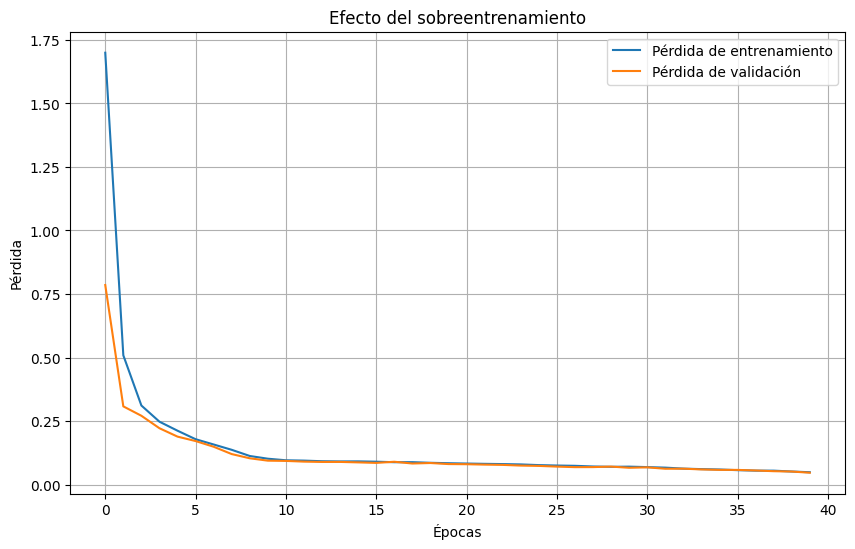

In [4]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Pérdida de entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida de validación')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.title('Efecto del sobreentrenamiento')
plt.legend()
plt.grid(True)
plt.show()

In [5]:
loss, accuracy = modelo.evaluate(x_test, y_test)
y_pred = modelo.predict(x_test)
print(f"Accuracy: {accuracy:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.9836 - loss: 0.0507
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
Accuracy: 0.9836


**E4:** Visualiza un par de cortes para verificar los resultados numéricos comparando con el ground truth.

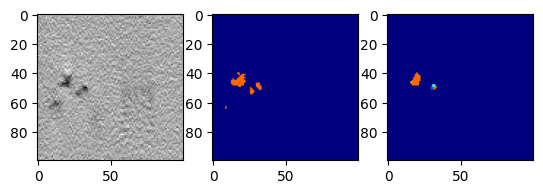

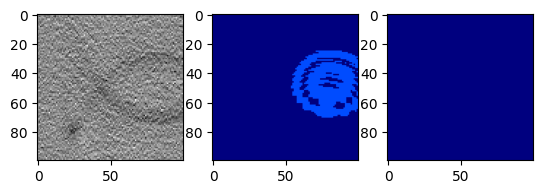

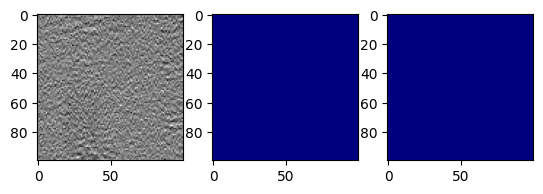

In [6]:
n_imgs, off = 3, 60

y_test_cat = np.argmax(y_test, axis = -1)
y_pred_cat = np.argmax(y_pred, axis= -1)

true_class, pred_class = '', ''

for i in range(n_imgs):
	fig = plt.figure()
	fig.add_subplot(1,3,1)
	plt.imshow(x_test[i+off, :, :], cmap = 'gray')
	fig.add_subplot(1,3,2)
	plt.imshow(y_test_cat[i+off, :, :], cmap='jet', vmin = 0, vmax = 5)
	fig.add_subplot(1,3,3)
	plt.imshow(y_pred_cat[i+off, :, :], cmap='jet', vmin=0, vmax = 5)
	plt.show()

Se obtienen resultados bastante malos sobretodo en la detección de una región grande. Aunque la precisión es muy alta, esto se pude deber a que la mayoría de las muestras son espacios vacíos por lo que el modelo acierta mucho ya que no hay nada, pero cuando aparece alguna figura, el modelo falla ya que sigue diciendo que no hay nada, por lo que parace haber un sobreajuste que provoca una mala generalización. 

**E5:** Repite los ejercicios 2 e 3 pero esta vez generando un dataset mayor añadiendo los cortes en los planos X-Z, a lo largo del eje Y, e Y-Z, a lo largo del eje X. Usa el parámetro *stride* para controlar el tamaño de los datos entrenamiento, dependiendo del hardware de cada equipo pueden aparecer problemas de memoría o dispararse el tiempo de entrenamiento si se usa el dataset  completo.


In [7]:
stride = 5
x_data_XZ, y_data_XZ = load_tomo_data_as_slices(tomo_path, tomo_gt_path, axis = 'Y', patch_size = 100, num_classes = 6, stride = stride)
x_data_YZ, y_data_YZ = load_tomo_data_as_slices(tomo_path, tomo_gt_path, axis = 'X', patch_size = 100, num_classes = 6, stride = stride)
x_data = np.concatenate((x_data_XY, x_data_XZ, x_data_YZ), axis = 0)
y_data = np.concatenate((y_data_XY, y_data_XZ, y_data_YZ), axis = 0)

model = unet_model(input_shape = (100,100,1))
model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])


x_train, x_test, y_train, y_test = train_test_split(
    x_data, y_data,
    test_size=0.2,      # 20% para test
    random_state=43    # Para que sea reproducible
)

In [8]:
es = EarlyStopping(monitor='val_loss', mode = 'min', verbose = 1, patience = 1)

history = model.fit(
		x_train,
		y_train,
        validation_split=0.2,
		epochs = 10,
		batch_size = 36,
		callbacks = [es]
)

Epoch 1/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 17s 802ms/step - accuracy: 0.9308 - loss: 0.6975 - val_accuracy: 0.9702 - val_loss: 0.2580
Epoch 2/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 14s 763ms/step - accuracy: 0.9697 - loss: 0.1879 - val_accuracy: 0.9702 - val_loss: 0.1485
Epoch 3/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 14s 781ms/step - accuracy: 0.9697 - loss: 0.1294 - val_accuracy: 0.9702 - val_loss: 0.1080
Epoch 4/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 15s 836ms/step - accuracy: 0.9697 - loss: 0.1021 - val_accuracy: 0.9702 - val_loss: 0.1009
Epoch 5/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 14s 782ms/step - accuracy: 0.9697 - loss: 0.0994 - val_accuracy: 0.9702 - val_loss: 0.0955
Epoch 6/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 14s 753ms/step - accuracy: 0.9697 - loss: 0.0958 - val_accuracy: 0.9703 - val_loss: 0.0945
Epoch 7/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 13s 736ms/step - accuracy: 0.9700 - loss: 0.0928 - val_accuracy: 0.9704 - val_loss: 0.0925
Epoch 8/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 14s 753ms/step - accuracy: 0.9714 - loss: 0.0914 - val_accu

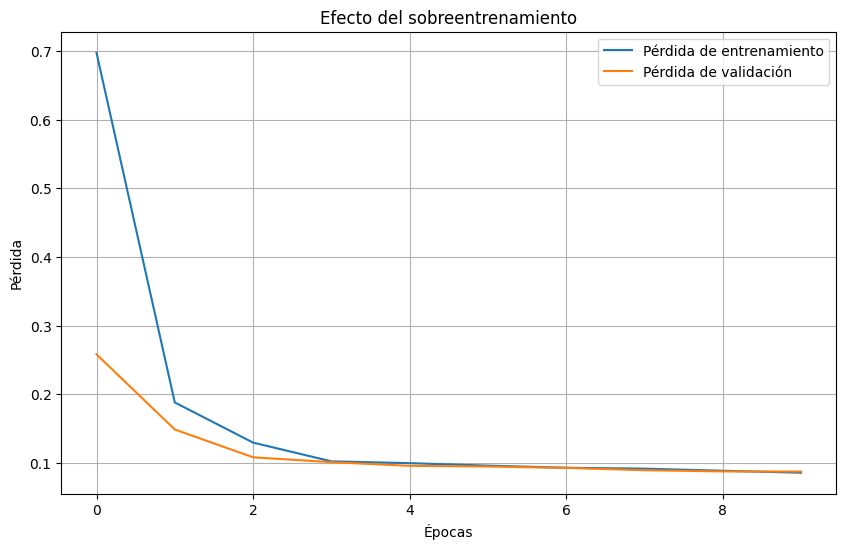

In [9]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Pérdida de entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida de validación')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.title('Efecto del sobreentrenamiento')
plt.legend()
plt.grid(True)
plt.show()

In [10]:
loss, accuracy = modelo.evaluate(x_test, y_test)
y_pred = modelo.predict(x_test)
print(f"Accuracy: {accuracy:.4f}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 160ms/step - accuracy: 0.9772 - loss: 0.0920
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 147ms/step
Accuracy: 0.9772


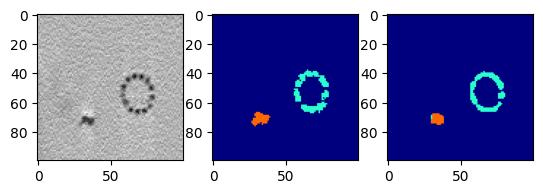

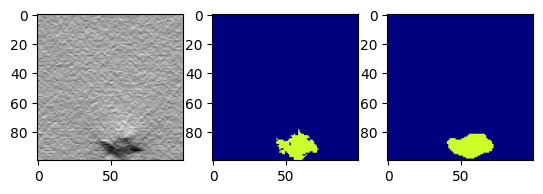

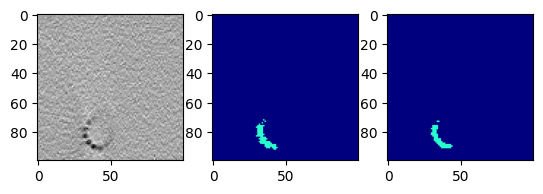

In [11]:
n_imgs, off = 3, 60

y_test_cat = np.argmax(y_test, axis = -1)
y_pred_cat = np.argmax(y_pred, axis= -1)

true_class, pred_class = '', ''

for i in range(n_imgs):
	fig = plt.figure()
	fig.add_subplot(1,3,1)
	plt.imshow(x_test[i+off, :, :], cmap = 'gray')
	fig.add_subplot(1,3,2)
	plt.imshow(y_test_cat[i+off, :, :], cmap='jet', vmin = 0, vmax = 5)
	fig.add_subplot(1,3,3)
	plt.imshow(y_pred_cat[i+off, :, :], cmap='jet', vmin=0, vmax = 5)
	plt.show()

Con un conjunto de entrenamiento mayor se obtiene un accuracy menor pero el modelo detecta mucho mejor las figuras de la tomografía, no es exacto pero obtienen muy buenos resultados. Por lo tanto, se ha demostrado que un aumento de datos, un conjunto de entrenamiento más grande con más muestras ha hecho que consigamos un modelo mucho mejor.